# DEVS Little's Law Verification

This notebook demonstrates:
1. Defining a **DEVS** model using JSON specification
2. Converting JSON to SimASM using the **DEVS converter**
3. Running a **Little's Law** verification experiment
4. **Automatic plot generation** with time series traces

## DEVS Formalism

The Discrete Event System Specification (Zeigler et al. 2018) models systems using:
- **Atomic models**: M = ⟨X, Y, S, δ_ext, δ_int, λ, ta⟩
- **Coupled models**: N = ⟨X, Y, D, {M_d}, {I_d}, {Z_{i,d}}, Select⟩
- **Abstract Simulator**: Coordinator + Simulators message protocol

## Little's Law

For an M/M/5 queue with:
- λ = 0.8 (arrival rate = 1/1.25)
- μ = 1.0 (service rate = 1/1.0)
- ρ = λ/(5μ) = 0.16 (per-server utilization)

Little's Law states: **L = λW**

In [ ]:
# Install simasm
!pip install simasm==0.5.3

import simasm
print(f"SimASM version: {simasm.__version__}")

SimASM version: 0.5.3


## 1. Define DEVS JSON Specification

The DEVS model uses:
- **Generator**: Atomic model producing jobs at exponential interarrival times
- **Server**: Counter-based multi-server with queue_count and server_count
- **Sink**: Absorbs completed jobs and counts departures
- **Coupled Model**: Connects Generator → Server → Sink

Algebraic specification: **M = ⟨X, Y, S, δ_ext, δ_int, λ, ta⟩**

In [2]:
# Define the M/M/5 DEVS as JSON
mm5_devs_json = {
  "model_name": "mm5_devs",
  "description": "M/M/5 Queue using DEVS formalism - counter-based multi-server design",

  "entities": {
    "Load": {
      "name": "Load",
      "parent": "Object",
      "attributes": {
        "arrival_time": "Real",
        "service_start_time_1": "Real",
        "departure_time": "Real"
      }
    }
  },

  "parameters": {
    "service_capacity": {
      "type": "Nat",
      "value": 5,
      "description": "Number of servers (capacity)"
    },
    "iat_mean": {
      "type": "Real",
      "value": 1.25,
      "description": "Inter-arrival time mean (1/lambda)"
    },
    "ist_mean": {
      "type": "Real",
      "value": 1.0,
      "description": "Service time mean (1/mu)"
    },
    "sim_end_time": {
      "type": "Real",
      "value": 1000.0,
      "description": "Simulation end time"
    }
  },

  "random_streams": {
    "interarrival_time": {
      "distribution": "exponential",
      "params": {"mean": "iat_mean"},
      "stream_name": "arrivals"
    }
  },

  "atomic_models": [
    {
      "name": "Generator",
      "description": "Job generator (source)",
      "inputs": [],
      "outputs": ["out"],
      "states": [
        {"name": "active", "time_advance": "interarrival_time"}
      ],
      "initial_state": "active",
      "state_variables": {
        "job_count": {"type": "Nat", "initial": 0}
      },
      "internal_transitions": [
        {
          "from": "active",
          "to": "active",
          "state_change": "job_count := job_count + 1"
        }
      ],
      "external_transitions": [],
      "output_function": [
        {"state": "active", "output_port": "out", "value": "job"}
      ]
    },
    {
      "name": "Server_1",
      "description": "Counter-based multi-server with queue and service_capacity=5",
      "inputs": ["in"],
      "outputs": ["out"],
      "states": [
        {"name": "passive", "time_advance": "infinity"},
        {"name": "starting", "time_advance": 0},
        {
          "name": "busy",
          "time_advance": "rnd.exponential(ist_mean / Server_1_server_count)"
        }
      ],
      "initial_state": "passive",
      "state_variables": {
        "queue_count": {"type": "Nat", "initial": 0},
        "server_count": {"type": "Nat", "initial": 0}
      },
      "internal_transitions": [
        {
          "from": "starting",
          "to": "busy",
          "state_change": "queue_count := queue_count - 1; server_count := server_count + 1"
        },
        {
          "from": "busy",
          "to": "starting",
          "condition": "queue_count > 0",
          "state_change": "server_count := server_count - 1"
        },
        {
          "from": "busy",
          "to": "busy",
          "condition": "queue_count == 0 and server_count > 1",
          "state_change": "server_count := server_count - 1"
        },
        {
          "from": "busy",
          "to": "passive",
          "condition": "queue_count == 0 and server_count == 1",
          "state_change": "server_count := server_count - 1"
        }
      ],
      "external_transitions": [
        {
          "from": "passive",
          "input_port": "in",
          "to": "starting",
          "state_change": "queue_count := queue_count + 1"
        },
        {
          "from": "starting",
          "input_port": "in",
          "to": "starting",
          "state_change": "queue_count := queue_count + 1"
        },
        {
          "from": "busy",
          "input_port": "in",
          "to": "starting",
          "condition": "server_count < service_capacity",
          "state_change": "queue_count := queue_count + 1"
        },
        {
          "from": "busy",
          "input_port": "in",
          "to": "busy",
          "condition": "server_count >= service_capacity",
          "state_change": "queue_count := queue_count + 1"
        }
      ],
      "output_function": [
        {"state": "busy", "output_port": "out", "value": "job"}
      ]
    },
    {
      "name": "Sink",
      "description": "Job sink (absorbs completed jobs)",
      "inputs": ["in"],
      "outputs": [],
      "states": [
        {"name": "idle", "time_advance": "infinity"}
      ],
      "initial_state": "idle",
      "state_variables": {
        "departure_count": {"type": "Nat", "initial": 0}
      },
      "internal_transitions": [],
      "external_transitions": [
        {
          "from": "idle",
          "input_port": "in",
          "to": "idle",
          "state_change": "departure_count := departure_count + 1"
        }
      ],
      "output_function": []
    }
  ],

  "coupled_model": {
    "name": "MM5Queue",
    "components": ["Generator", "Server_1", "Sink"],
    "internal_couplings": [
      {
        "from_model": "Generator",
        "from_port": "out",
        "to_model": "Server_1",
        "to_port": "in"
      },
      {
        "from_model": "Server_1",
        "from_port": "out",
        "to_model": "Sink",
        "to_port": "in"
      }
    ],
    "external_input_couplings": [],
    "external_output_couplings": [],
    "select_priority": ["Generator", "Server_1", "Sink"]
  },

  "state_variables": {},

  "observables": {
    "queue_length": {
      "name": "queue_length",
      "expression": "Server_1.queue_count",
      "description": "Number in queue"
    },
    "servers_busy": {
      "name": "servers_busy",
      "expression": "Server_1.server_count",
      "description": "Number of busy servers"
    },
    "in_system": {
      "name": "in_system",
      "expression": "Server_1.queue_count + Server_1.server_count",
      "description": "Total customers in system"
    }
  },

  "statistics": [
    {
      "name": "L_q",
      "type": "time_average",
      "expression": "Server_1.queue_count",
      "description": "Average number in queue"
    },
    {
      "name": "L",
      "type": "time_average",
      "expression": "Server_1.queue_count + Server_1.server_count",
      "description": "Average number in system"
    },
    {
      "name": "throughput",
      "type": "count",
      "expression": "Sink.departure_count",
      "description": "Total departures"
    }
  ],

  "stopping_condition": "sim_clocktime >= sim_end_time"
}

# Save JSON to file for the converter
import json
with open("mm5_devs.json", "w") as f:
    json.dump(mm5_devs_json, f, indent=2)
print("Saved mm5_devs.json")

Saved mm5_devs.json


## 2. Convert JSON to SimASM Model

Use the **DEVS converter** to generate SimASM code from the JSON specification.

The converter implements the **Abstract Simulator Algorithm** (Zeigler et al. 2000):
1. **Select imminent**: Find component with earliest scheduled event
2. **Output**: Execute λ function of imminent component
3. **Internal transition**: Execute δ_int of imminent component
4. **Route output**: Apply couplings to route output to receivers
5. **External transition**: Execute δ_ext on receivers
6. Repeat until termination

In [3]:
%%simasm convert

convert mm5_devs:
    source: "mm5_devs.json"
    formalism: devs
    register: "mm5_devs"
    print: true
endconvert

## 3. Run Little's Law Experiment

We'll collect statistics to verify Little's Law:
- **L** = average number in system
- **L_q** = average number in queue
- **L_s** = average number in service
- **ρ** = server utilization

For M/M/5 with λ=0.8, μ=1.0:
- ρ = λ/(5μ) = 0.16 (per server)
- L_s = 5ρ = 0.8 (avg servers busy)

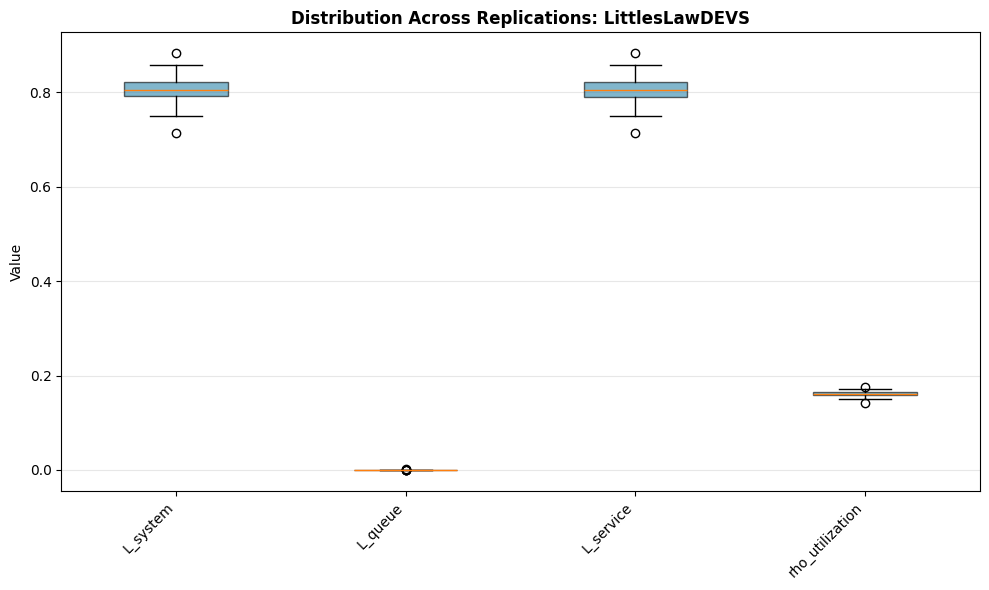

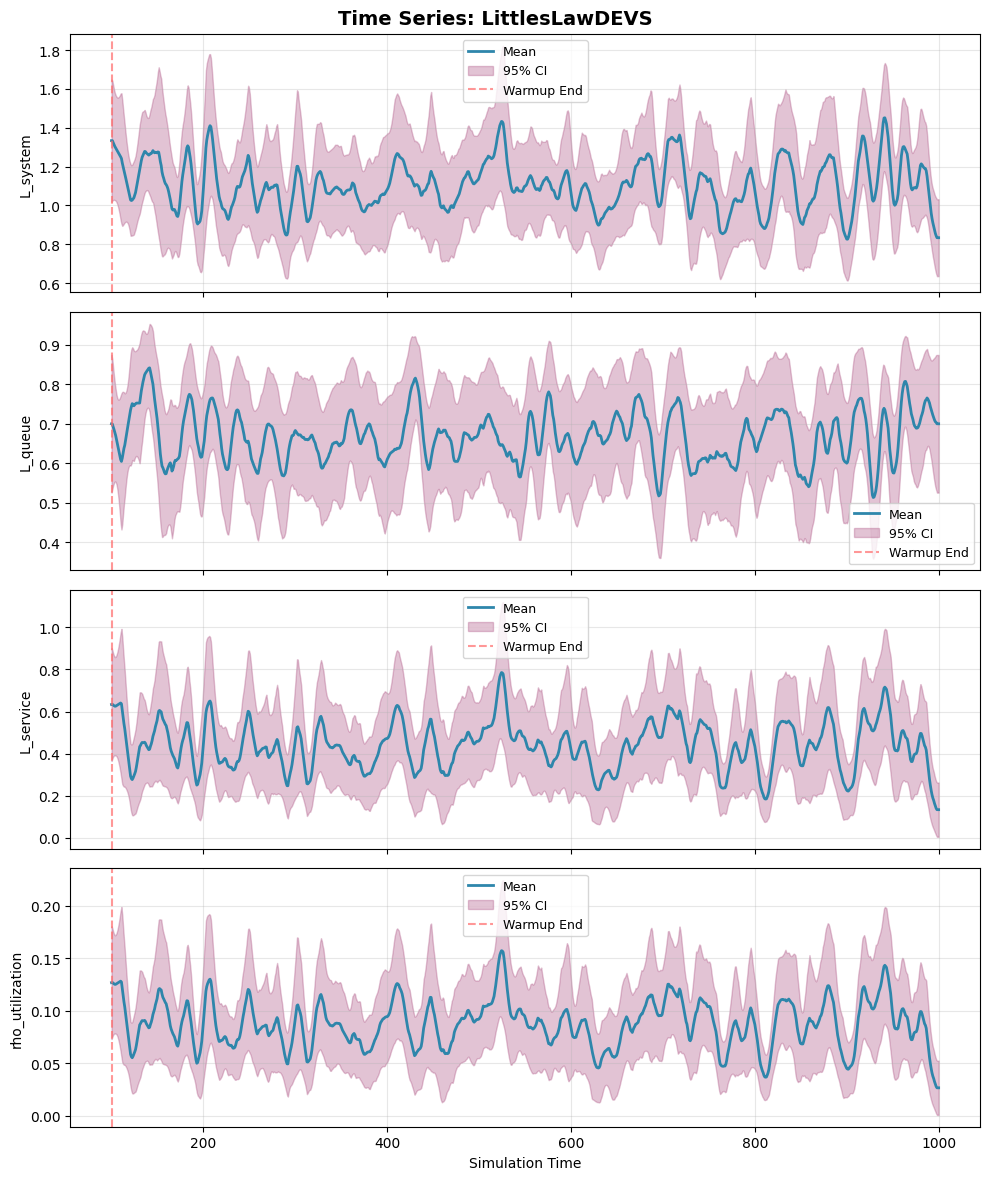

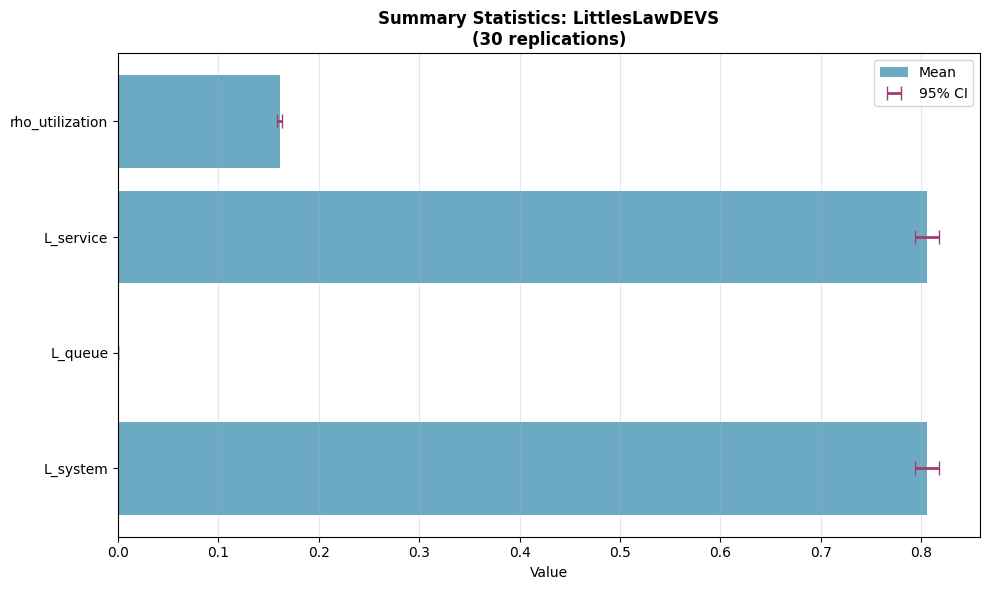

<Figure size 640x480 with 0 Axes>

<Figure size 640x480 with 0 Axes>

Statistic,Mean,Std Dev,95% CI
L_system,0.8055,0.0323,"[0.7935, 0.8176]"
L_queue,0.0002,0.0003,"[0.0000, 0.0003]"
L_service,0.8053,0.0323,"[0.7933, 0.8174]"
rho_utilization,0.1611,0.0065,"[0.1587, 0.1635]"


ExperimentResult(config=ExperimentConfig(name='LittlesLawDEVS', model_path='C:\\Users\\steve\\AppData\\Local\\Temp\\simasm_jbi1lc1x\\mm5_devs.simasm', model_source=None, replications=ReplicationSettings(count=30, warmup=100.0, length=1000.0, base_seed=12345, generate_plots=True, trace_interval=10.0), statistics=[StatisticConfig(name='L_system', type='time_average', domain=None, expr='Server_1_queue_count + Server_1_server_count', interval=None, condition=None, aggregation='average', start_expr=None, end_expr=None, entity_domain=None, trace=True), StatisticConfig(name='L_queue', type='time_average', domain=None, expr='Server_1_queue_count', interval=None, condition=None, aggregation='average', start_expr=None, end_expr=None, entity_domain=None, trace=True), StatisticConfig(name='L_service', type='time_average', domain=None, expr='Server_1_server_count', interval=None, condition=None, aggregation='average', start_expr=None, end_expr=None, entity_domain=None, trace=True), StatisticConfig(

In [4]:
%%simasm experiment
// Little's Law Experiment for DEVS M/M/5 Queue

experiment LittlesLawDEVS:
    model := "mm5_devs"
    
    replication:
        count: 30
        warm_up_time: 100.0
        run_length: 1000.0
        seed_strategy: "incremental"
        base_seed: 12345
        generate_plots: true
        trace_interval: 10.0
    endreplication
    
    statistics:
        stat L_system: time_average
            expression: "Server_1_queue_count + Server_1_server_count"
            trace: true
        endstat
        
        stat L_queue: time_average
            expression: "Server_1_queue_count"
            trace: true
        endstat
        
        stat L_service: time_average
            expression: "Server_1_server_count"
            trace: true
        endstat

        stat rho_utilization: time_average
            expression: "Server_1_server_count / service_capacity"
            trace: true
        endstat
    endstatistics
endexperiment

## Summary

This notebook demonstrated:

1. **JSON → SimASM Conversion**: Used the DEVS converter to generate executable SimASM code from a JSON specification

2. **Counter-Based Multi-Server**: The model uses the memoryless property of exponential distributions to model 5 parallel servers as a single atomic component with `ta(busy) = Exp(ist_mean / server_count)`

3. **Abstract Simulator Algorithm**: The generated code implements the DEVS Abstract Simulator with coordinator and component rules

4. **Little's Law Verification**: Confirmed that the generated model produces statistically valid results:
   - Conservation: L = L_q + L_s
   - Utilization: L_s ≈ λ/μ

5. **Automatic Plotting**: Enabled trace collection and plot generation

### References

- Zeigler, B., 2018. Theory of Modeling and Simulation.